In [21]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
data=pd.read_csv('IMDB Dataset.csv')

In [25]:
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_text'] = data['review'].apply(preprocess)
data.head()

,review,sentiment,clean_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...


In [26]:
vectorizer=TfidfVectorizer(max_features=5000)
X=vectorizer.fit_transform(data['clean_text'])
y=data['sentiment']

In [27]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [28]:
model=MultinomialNB()
model.fit(X_train,y_train)


MultinomialNB()

In [29]:
y_pred=model.predict(X_test)

In [30]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Classification Report",classification_report(y_test,y_pred))


Accuracy 0.8526
Classification Report               precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



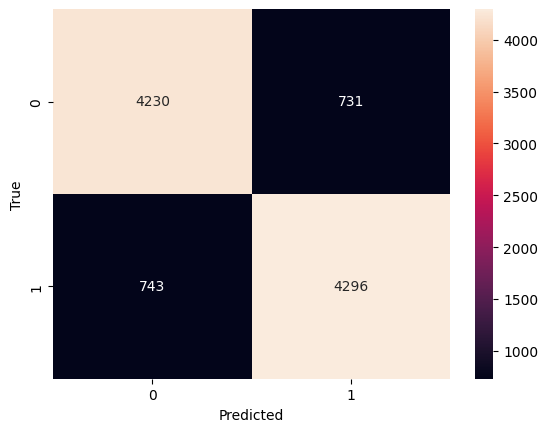

In [31]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [32]:
text=["This movie was fantastic and inspiring"]
clean=preprocess(text[0])
vector=vectorizer.transform([clean])
prediction=model.predict(vector)
print("Predicted Score:",prediction[0])

Predicted Score: positive


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

all_models={
    "Naive Bayes":MultinomialNB(),
    "Logistic Regression":LogisticRegression(max_iter=200),
    "SVM":LinearSVC(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boosting":GradientBoostingClassifier()}

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

results=[]
for name, model_instance in all_models.items():
  model_instance.fit(X_train,y_train)
  y_pred=model_instance.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred, pos_label='positive')
  recall=recall_score(y_test,y_pred, pos_label='positive')
  f1=f1_score(y_test,y_pred, pos_label='positive')
  results.append([name,accuracy,precision,recall,f1])

In [36]:
results_df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1 Score'])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8526,0.854585,0.852550,0.853566
1,Logistic Regression,0.8942,0.885681,0.907124,0.896275
2,SVM,0.8897,0.884075,0.898988,0.891469
3,Random Forest,0.8489,0.858100,0.838857,0.848369
4,Gradient Boosting,0.8162,0.790103,0.865053,0.825881


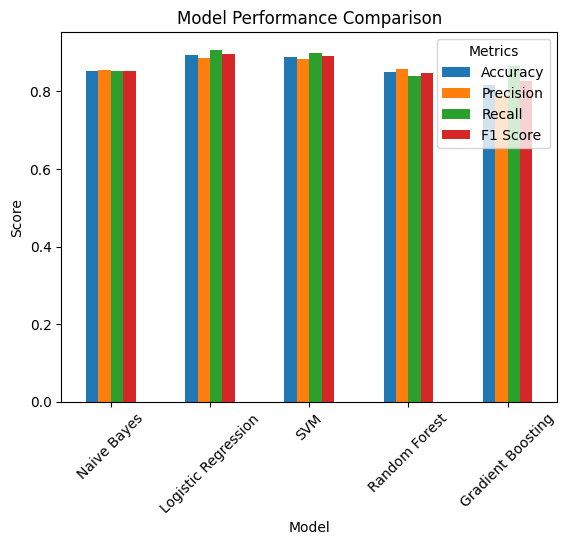

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind="bar")
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.show()

**Based on the comparision the best model is Logistic Regression**

In [38]:
model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

LogisticRegression(max_iter=200)

In [39]:
y_pred=model.predict(X_test)

In [40]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Classification Report",classification_report(y_test,y_pred))

Accuracy 0.8942
Classification Report               precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



###Increasing The Accuracy

In [41]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_search = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\nAccuracy of tuned Logistic Regression model:", accuracy_score(y_test, y_pred_tuned))
print("Classification Report of tuned Logistic Regression model:\n", classification_report(y_test, y_pred_tuned))


Best parameters:  {'C': 1, 'solver': 'saga'}
Best cross-validation accuracy:  0.8878

Accuracy of tuned Logistic Regression model: 0.8942
Classification Report of tuned Logistic Regression model:
               precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [42]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)